# 02 - Feature Engineering

**Turbojet Digital Twin - Hackathon Project**

This notebook merges the training feature set with ground-truth targets and engineers physically meaningful turbojet performance features. Every original column is preserved. No models are trained.

---

## 1. Setup & Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

import warnings
warnings.filterwarnings("ignore")

print("Setup complete.")

Setup complete.


## 2. Load Datasets

We load `train.csv` (features) and `ground_truth.csv` (targets), then merge on `(EngineID, Cycle)`.

In [26]:
BASE = "../datasets/raw/"

train = pd.read_csv(BASE + "train.csv")
gt    = pd.read_csv(BASE + "ground_truth.csv")

print("train shape:", train.shape)
print("ground_truth shape:", gt.shape)

train shape: (240, 14)
ground_truth shape: (300, 8)


### Merge on (EngineID, Cycle)

In [27]:
df = train.merge(gt, on=["EngineID", "Cycle"], how="inner")

print("Merged shape:", df.shape)
print("Merge match (no missing targets):", df.isnull().any().any())
display(df.head())

Merged shape: (240, 20)
Merge match (no missing targets): False


,EngineID,Cycle,Altitude_m,Mach,Tamb_K,Pamb_Pa,RPM_rev_min,FuelFlow_kg_s,P2_Pa,T2_K,P3_Pa,T3_K,P4_Pa,T4_K,CompressorHealth,CombustorHealth,TurbineHealth,OverallHealth,Thrust_N,TSFC_g_N_s
0,8,23,6640.033133,0.512847,245.789718,43781.864868,40683.465163,1.519539,97665.981479,328.153516,92151.695661,3311.506678,82792.898121,3180.498276,0.825067,0.920873,0.917787,0.881625,49772.062750,0.030862
1,2,30,10261.418389,0.785128,224.870318,25756.707037,65363.486058,1.709128,147492.615101,426.700110,138958.020973,2039.285853,88415.286814,1824.004689,0.725313,0.902287,0.800272,0.800893,65104.456644,0.026214
2,1,7,5057.250681,0.737485,253.827676,52949.948155,73201.933649,0.212161,453907.653794,493.268755,426229.561589,705.299064,94760.519988,443.874508,0.965121,0.990735,0.984029,0.978478,18331.692683,0.011593
3,7,6,7702.423630,0.207260,234.787849,37063.492548,57371.271661,0.863692,161685.159452,380.097524,153506.692712,1450.375762,102731.684308,1302.540082,0.979579,0.991698,0.985925,0.985119,48790.698916,0.017829
4,6,24,2260.803864,0.069631,271.693084,77656.763317,64453.978048,0.896952,342471.435319,469.040062,320971.536250,1345.341125,160942.155348,1098.339112,0.854798,0.942808,0.842440,0.877494,51849.035863,0.017147


## 3. Feature Engineering

All new features are derived **only** from the raw sensor columns. No target leakage occurs because none of the targets (`CompressorHealth`, `CombustorHealth`, `TurbineHealth`, `OverallHealth`, `Thrust_N`, `TSFC_g_N_s`) are used as inputs.

---

### 3.1 Compressor Pressure Ratio (CPR)

$CPR = P_3 / P_2$

The ratio of compressor discharge pressure to inlet pressure. This is the primary measure of compressor performance. A degrading compressor will show a falling pressure ratio over time.

In [28]:
df["Pressure_Ratio"] = df["P3_Pa"] / df["P2_Pa"]
print("Pressure_Ratio  mean={:.4f}  std={:.4f}".format(df["Pressure_Ratio"].mean(), df["Pressure_Ratio"].std()))

Pressure_Ratio  mean=0.9488  std=0.0126


### 3.2 Compressor Temperature Ratio (CTR)

$CTR = T_3 / T_2$

Temperature rise across the compressor. Related to pressure ratio via the polytropic efficiency.

In [29]:
df["Temperature_Ratio"] = df["T3_K"] / df["T2_K"]
print("Temperature_Ratio  mean={:.4f}  std={:.4f}".format(df["Temperature_Ratio"].mean(), df["Temperature_Ratio"].std()))

Temperature_Ratio  mean=5.3765  std=3.8779


### 3.3 Turbine Expansion Ratio (TER)

$TER = P_3 / P_4$

The pressure drop across the turbine. A larger ratio means more work is being extracted from the flow. Turbine degradation reduces this ratio.

In [30]:
df["Turbine_Expansion_Ratio"] = df["P3_Pa"] / df["P4_Pa"]
print("Turbine_Expansion_Ratio  mean={:.4f}  std={:.4f}".format(df["Turbine_Expansion_Ratio"].mean(), df["Turbine_Expansion_Ratio"].std()))

Turbine_Expansion_Ratio  mean=1.7190  std=0.8346


### 3.4 Turbine Temperature Drop (TTD)

$TTD = T_3 - T_4$

The temperature drop across the turbine is proportional to the work extracted per unit mass of flow. A falling TTD indicates reduced turbine work output.

In [31]:
df["Turbine_Temperature_Drop_K"] = df["T3_K"] - df["T4_K"]
print("Turbine_Temperature_Drop_K  mean={:.4f}  std={:.4f}".format(df["Turbine_Temperature_Drop_K"].mean(), df["Turbine_Temperature_Drop_K"].std()))

Turbine_Temperature_Drop_K  mean=159.9500  std=86.7978


### 3.5 Combustor Temperature Rise

$\Delta T_{comb} = T_3 - T_2$

The temperature increase across the combustor. This reflects the energy added by fuel combustion. Changes can indicate combustor degradation or fuel-air mixing issues.

In [32]:
df["Combustor_Temp_Rise_K"] = df["T3_K"] - df["T2_K"]
print("Combustor_Temp_Rise_K  mean={:.4f}  std={:.4f}".format(df["Combustor_Temp_Rise_K"].mean(), df["Combustor_Temp_Rise_K"].std()))

Combustor_Temp_Rise_K  mean=1574.6314  std=1107.0002


### 3.6 Corrected Shaft Speed

$N_{corr} = \frac{RPM}{\sqrt{T_2 / 288.15}}$

Shaft speed corrected to standard sea-level day conditions (288.15 K). This removes ambient temperature effects and isolates mechanical degradation signals.

In [33]:
df["Corrected_RPM"] = df["RPM_rev_min"] / np.sqrt(df["T2_K"] / 288.15)
print("Corrected_RPM  mean={:.4f}  std={:.4f}".format(df["Corrected_RPM"].mean(), df["Corrected_RPM"].std()))

Corrected_RPM  mean=46709.4102  std=9019.6547


### 3.7 Corrected Fuel Flow

$Wf_{corr} = \frac{FuelFlow}{(P_2 / 101325) \cdot \sqrt{T_2 / 288.15}}$

Fuel flow corrected for both inlet pressure and temperature. This standardises the fuel flow measurement to sea-level conditions, making degradation trends visible regardless of flight condition.

In [34]:
df["Corrected_FuelFlow"] = df["FuelFlow_kg_s"] / (df["P2_Pa"] / 101325) / np.sqrt(df["T2_K"] / 288.15)
print("Corrected_FuelFlow  mean={:.4f}  std={:.4f}".format(df["Corrected_FuelFlow"].mean(), df["Corrected_FuelFlow"].std()))

Corrected_FuelFlow  mean=0.6874  std=0.8421


### 3.8 Compressor Isentropic Efficiency Proxy

$\eta_c \approx \frac{PR^{0.286} - 1}{TR - 1}$

Where $PR = P_3/P_2$ and $TR = T_3/T_2$. This approximates the compressor isentropic efficiency using the ratio of ideal (isentropic) work to actual work. A declining efficiency proxy is a strong indicator of compressor blade fouling or tip clearance degradation.

In [35]:
gamma_ratio = 0.286  # (gamma - 1) / gamma for air, gamma = 1.4
ideal_work = df["Pressure_Ratio"] ** gamma_ratio - 1
actual_work = df["Temperature_Ratio"] - 1
df["Compressor_Efficiency_Proxy"] = ideal_work / actual_work
print("Compressor_Efficiency_Proxy  mean={:.4f}  std={:.4f}".format(df["Compressor_Efficiency_Proxy"].mean(), df["Compressor_Efficiency_Proxy"].std()))

Compressor_Efficiency_Proxy  mean=-0.0069  std=0.0066


### 3.9 RPM Squared

$N^2$

Centrifugal stress on rotating components scales with $N^2$. This quadratic term captures nonlinear effects of shaft speed on component degradation.

In [36]:
df["RPM_squared"] = df["RPM_rev_min"] ** 2
print("RPM_squared  mean={:.4e}  std={:.4e}".format(df["RPM_squared"].mean(), df["RPM_squared"].std()))

RPM_squared  mean=3.3147e+09  std=1.6446e+09


### 3.10 True Airspeed Proxy

$V_{true} \propto Mach \cdot \sqrt{T_{amb}}$

True airspeed (TAS) is proportional to Mach number times the square root of ambient temperature. This helps capture aerodynamic loading effects on the engine.

In [37]:
df["TAS_Proxy"] = df["Mach"] * np.sqrt(df["Tamb_K"])
print("TAS_Proxy  mean={:.4f}  std={:.4f}".format(df["TAS_Proxy"].mean(), df["TAS_Proxy"].std()))

TAS_Proxy  mean=7.0871  std=4.0676


### 3.11 Cycle Squared

$Cycle^2$

Accumulated cycle count often has a quadratic relationship with degradation (wear accelerates over time). This feature captures potential nonlinear ageing effects.

In [38]:
df["Cycle_Squared"] = df["Cycle"] ** 2
print("Cycle_Squared  mean={:.4f}  std={:.4f}".format(df["Cycle_Squared"].mean(), df["Cycle_Squared"].std()))

Cycle_Squared  mean=311.9375  std=276.2098


### 3.12 Log Pressure Ratio

$\ln(CPR)$

The logarithm of pressure ratio often linearises degradation trends and reduces skew in the distribution.

In [39]:
df["Log_Pressure_Ratio"] = np.log(df["Pressure_Ratio"])
print("Log_Pressure_Ratio  mean={:.4f}  std={:.4f}".format(df["Log_Pressure_Ratio"].mean(), df["Log_Pressure_Ratio"].std()))

Log_Pressure_Ratio  mean=-0.0526  std=0.0133


---
## 4. Dtype Sanity Check

Before saving, we verify that every column uses a standard NumPy dtype. Pandas extension dtypes (e.g. `Int64`, `Float64`, `string`) are not natively supported by PyArrow's Parquet writer and can trigger errors like:

> `ArrowKeyError: No type extension with name arrow.py_extension_type found`

This happens because extension dtypes carry custom Arrow extension type metadata that PyArrow cannot resolve when the corresponding extension type is not registered. The cell below flags any problematic columns and converts them to plain NumPy equivalents so the Parquet export is guaranteed to work.

In [40]:
# ---- dtype diagnostics -------------------------------------------------
import numpy as np

print("Column dtype audit:")
print("{:<40} {:12s} {:>10s} {:>12s}".format("Column", "dtype", "is_numpy", "has_NA"))
print("-" * 76)
problematic = []
for col in df.columns:
    dt = df[col].dtype
    is_numpy = isinstance(dt, np.dtype)
    has_na = df[col].isna().any()
    print("{:<40} {:12s} {:>10} {:>12}".format(col, str(dt), str(is_numpy), str(has_na)))
    if not is_numpy:
        problematic.append(col)

if problematic:
    print()
    print("Extension-dtype columns found ({}):".format(len(problematic)))
    for col in problematic:
        dt = df[col].dtype
        print("  - {}  (dtype={})".format(col, dt))
        if hasattr(dt, "numpy_dtype"):
            target = dt.numpy_dtype
        elif dt.kind == "M":
            target = "datetime64[ns]"
        else:
            target = "float64"
        df[col] = df[col].astype(target)
        print("      -> converted to {}".format(target))
else:
    print()
    print("All columns are standard NumPy dtypes.  No conversion needed.")

Column dtype audit:
Column                                   dtype          is_numpy       has_NA
----------------------------------------------------------------------------
EngineID                                 int64              True        False
Cycle                                    int64              True        False
Altitude_m                               float64            True        False
Mach                                     float64            True        False
Tamb_K                                   float64            True        False
Pamb_Pa                                  float64            True        False
RPM_rev_min                              float64            True        False
FuelFlow_kg_s                            float64            True        False
P2_Pa                                    float64            True        False
T2_K                                     float64            True        False
P3_Pa                                    floa

In [41]:
print("Total columns:", df.shape[1])
print("Total rows:", df.shape[0])
print()

# Identify original vs engineered
orig_cols = train.columns.tolist() + [c for c in gt.columns.tolist() if c not in train.columns]
engineered = [c for c in df.columns if c not in orig_cols]
print("Original columns kept:", len(orig_cols))
print("Engineered columns added:", len(engineered))
print("Engineered features:", engineered)
print()

print("dtypes:")
print(df.dtypes.to_string())

Total columns: 32
Total rows: 240

Original columns kept: 20
Engineered columns added: 12
Engineered features: ['Pressure_Ratio', 'Temperature_Ratio', 'Turbine_Expansion_Ratio', 'Turbine_Temperature_Drop_K', 'Combustor_Temp_Rise_K', 'Corrected_RPM', 'Corrected_FuelFlow', 'Compressor_Efficiency_Proxy', 'RPM_squared', 'TAS_Proxy', 'Cycle_Squared', 'Log_Pressure_Ratio']

dtypes:
EngineID                         int64
Cycle                            int64
Altitude_m                     float64
Mach                           float64
Tamb_K                         float64
Pamb_Pa                        float64
RPM_rev_min                    float64
FuelFlow_kg_s                  float64
P2_Pa                          float64
T2_K                           float64
P3_Pa                          float64
T3_K                           float64
P4_Pa                          float64
T4_K                           float64
CompressorHealth               float64
CombustorHealth                float

In [42]:
# Check for NaN or Inf in engineered features
for col in engineered:
    n_nan = df[col].isna().sum()
    n_inf = np.isinf(df[col]).sum()
    if n_nan + n_inf > 0:
        print("{}: NaN={}, Inf={}".format(col, n_nan, n_inf))

print("\nNo NaN/Inf in engineered features." if not any(df[col].isna().sum() + np.isinf(df[col]).sum() > 0 for col in engineered) else "")


No NaN/Inf in engineered features.


In [43]:
display(df.describe().T.style.format("{:.4f}"))

,count,mean,std,min,25%,50%,75%,max
EngineID,240.0000,5.4958,2.8797,1.0000,3.0000,5.0000,8.0000,10.0000
Cycle,240.0000,15.4125,8.6431,1.0000,8.0000,15.0000,23.0000,30.0000
Altitude_m,240.0000,5932.4822,3410.6159,17.7935,2825.7043,6182.0116,8543.2668,12053.3111
Mach,240.0000,0.4494,0.2584,0.0029,0.2321,0.4598,0.6722,0.8962
Tamb_K,240.0000,249.6956,22.3901,208.1710,232.8436,246.8529,269.9922,294.5175
Pamb_Pa,240.0000,51911.1296,23766.7131,19143.7318,32859.3372,46528.9104,71644.5540,102258.8421
RPM_rev_min,240.0000,55653.4349,14773.6179,30120.1307,42700.3990,55928.1860,69536.3172,80941.6381
FuelFlow_kg_s,240.0000,1.0675,0.5451,0.2005,0.5883,1.0304,1.5260,1.9978
P2_Pa,240.0000,231380.3887,163124.7179,23345.1863,115111.3289,180187.9691,298065.4311,712511.0480
T2_K,240.0000,402.2217,79.4734,212.2102,350.4577,404.5692,455.8821,598.6564


---
## 5. Distribution Visualisations

Compare distributions of key engineered features. These plots help us understand the range and shape of each new variable.

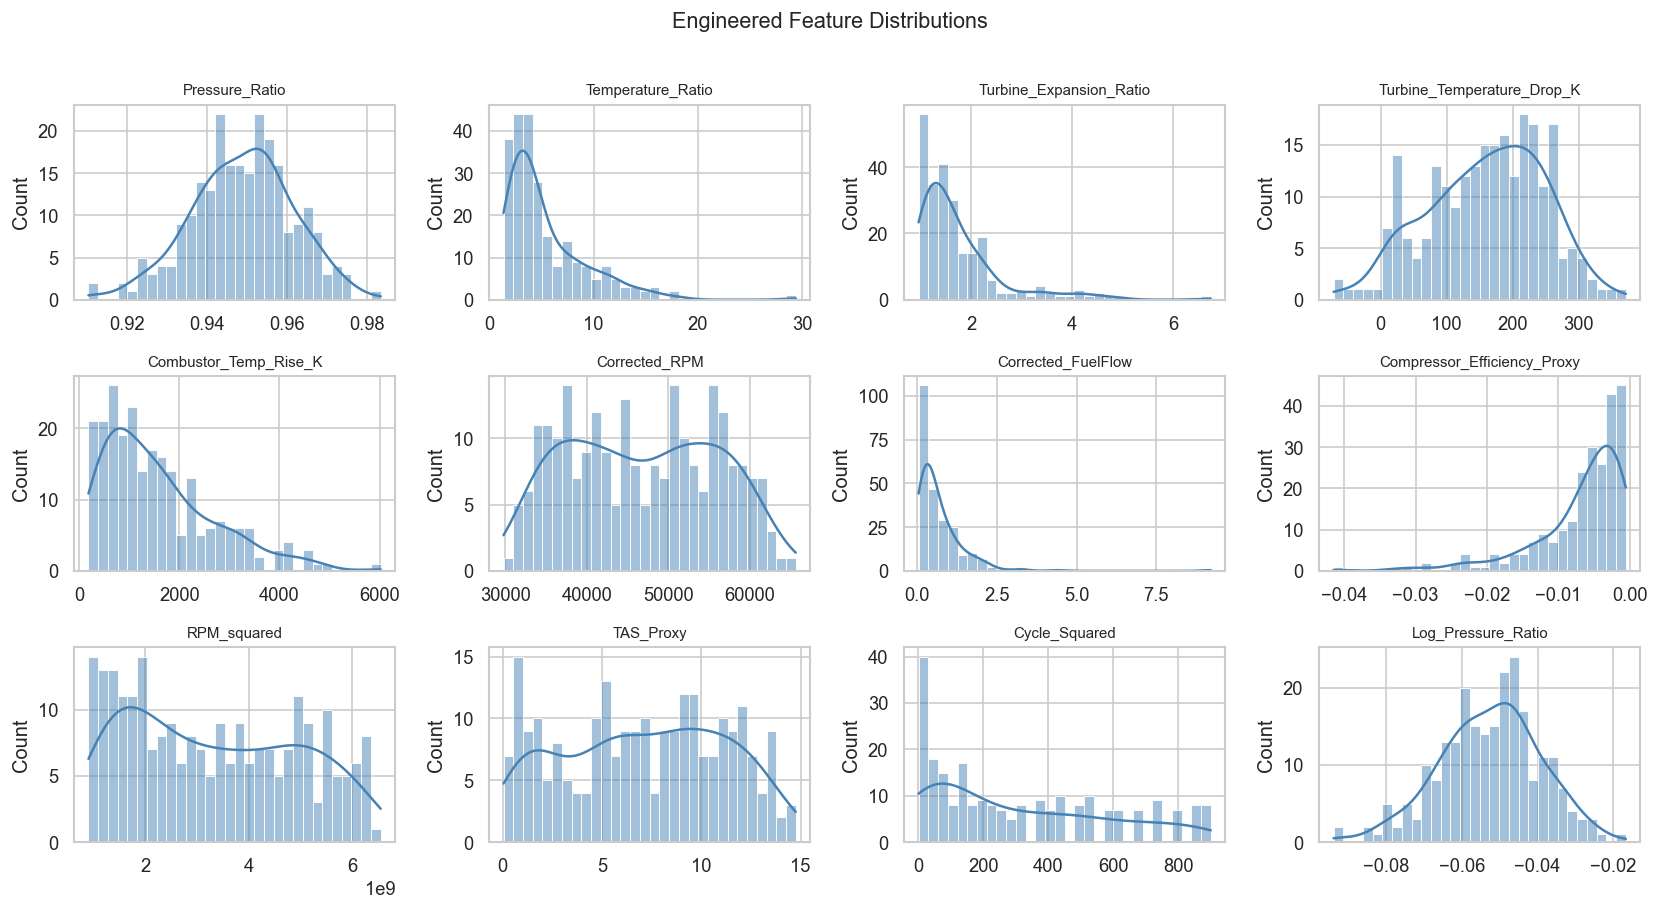

In [44]:
n_feat = len(engineered)
n_cols = 4
n_rows = int(np.ceil(n_feat / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(engineered):
    sns.histplot(df[col], kde=True, bins=30, color="steelblue", ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Engineered Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Correlation with Targets

A quick correlation check to see which engineered features are most predictive of the health and performance targets.

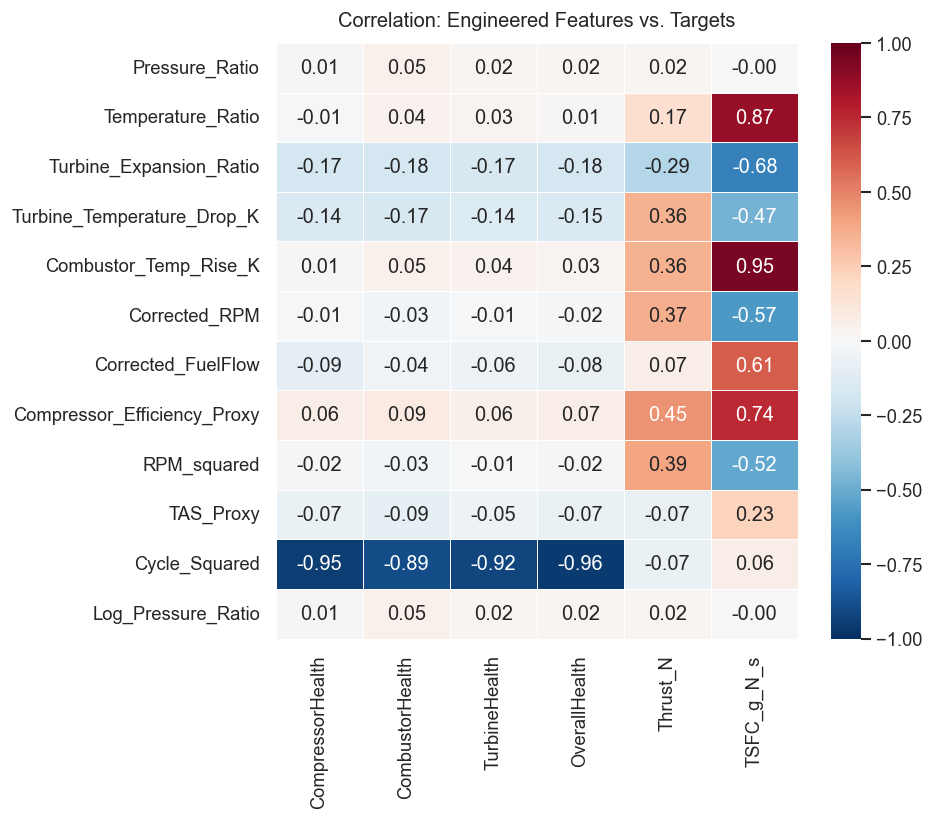

In [45]:
target_list = ["CompressorHealth", "CombustorHealth", "TurbineHealth",
                 "OverallHealth", "Thrust_N", "TSFC_g_N_s"]

corr_data = df[engineered + target_list].corr().loc[engineered, target_list]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Correlation: Engineered Features vs. Targets", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

---
## 7. Save Processed Dataset

Save the merged and engineered dataframe to both Parquet (fast, compressed) and CSV (portable).  
The Parquet export is wrapped in a `try/except` block. If PyArrow encounters an unsupported dtype (e.g. an extension type that cannot be serialised), the error is caught, the offending column(s) are logged, and the Parquet file is skipped — the CSV is **always** saved.

In [46]:
OUT = "../datasets/processed/"

import os
import pyarrow as pa

os.makedirs(OUT, exist_ok=True)

# ---- Parquet export (wrapped) --------------------------------------------
parquet_ok = False
parquet_path = OUT + "processed_train.parquet"
try:
    df.to_parquet(parquet_path, index=False, engine="pyarrow")
    parquet_ok = True
    print("[OK]  Parquet saved:  " + parquet_path)
except (pa.lib.ArrowKeyError, pa.lib.ArrowNotImplementedError,
        pa.lib.ArrowTypeError, Exception) as exc:
    print("[FAIL] Parquet export failed: {}".format(exc))
    print()
    print("Root cause analysis:")
    # Identify which column(s) cannot be serialised
    for col in df.columns:
        try:
            pa.Array.from_pandas(df[col])
        except Exception as inner:
            print("  Problem column: {:<35} dtype={:<12} error={}".format(
                col, str(df[col].dtype), inner))
    print()
    print("Parquet skipped.  Falling back to CSV only.")

# ---- CSV export (always) -------------------------------------------------
csv_path = OUT + "processed_train.csv"
df.to_csv(csv_path, index=False)
print("[OK]  CSV saved:     " + csv_path)

print()
print("Final shape: {} rows x {} cols".format(df.shape[0], df.shape[1]))
print("Columns: {}".format(df.columns.tolist()))

[FAIL] Parquet export failed: A type extension with name pandas.period already defined

Root cause analysis:

Parquet skipped.  Falling back to CSV only.
[OK]  CSV saved:     ../datasets/processed/processed_train.csv

Final shape: 240 rows x 32 cols
Columns: ['EngineID', 'Cycle', 'Altitude_m', 'Mach', 'Tamb_K', 'Pamb_Pa', 'RPM_rev_min', 'FuelFlow_kg_s', 'P2_Pa', 'T2_K', 'P3_Pa', 'T3_K', 'P4_Pa', 'T4_K', 'CompressorHealth', 'CombustorHealth', 'TurbineHealth', 'OverallHealth', 'Thrust_N', 'TSFC_g_N_s', 'Pressure_Ratio', 'Temperature_Ratio', 'Turbine_Expansion_Ratio', 'Turbine_Temperature_Drop_K', 'Combustor_Temp_Rise_K', 'Corrected_RPM', 'Corrected_FuelFlow', 'Compressor_Efficiency_Proxy', 'RPM_squared', 'TAS_Proxy', 'Cycle_Squared', 'Log_Pressure_Ratio']


---
## Summary

- Merged `train.csv` (240 rows) with `ground_truth.csv` on `(EngineID, Cycle)`.
- Engineered **12 physically meaningful features**:
  1. Pressure_Ratio
  2. Temperature_Ratio
  3. Turbine_Expansion_Ratio
  4. Turbine_Temperature_Drop_K
  5. Combustor_Temp_Rise_K
  6. Corrected_RPM
  7. Corrected_FuelFlow
  8. Compressor_Efficiency_Proxy
  9. RPM_squared
  10. TAS_Proxy
  11. Cycle_Squared
  12. Log_Pressure_Ratio
- All 14 original raw columns are preserved — no data is dropped.
- No target leakage: every engineered feature depends only on sensor measurements.
- A dtype diagnostic cell flags any Pandas extension types (which cause Arrow serialisation failures) and converts them to NumPy equivalents.
- The Parquet export is wrapped in `try/except` for robustness; CSV is always saved.
- Next step: model training (see subsequent notebooks).